# Analytical and HiStrA Overturning Analysis of a Scoured Wall

## Objective

This notebook compares the nonlinear HiStrA response of six foundation-scour scenarios with a rigid-body rocking model. For every remaining-support ratio $b/B$, it:

1. calculates foundation and pier/wall weight and their combined centroid;
2. locates the scenario-specific scour-front pivot;
3. calculates the restoring arm $d_1$, load arm $d_2$, and theoretical critical load;
4. runs `Vert`, applies the selected scour, and runs the live-load ArcLength analysis;
5. checks strict force/residual equilibrium before accepting every step;
6. compares the numerical and theoretical post-peak response down to zero load;
7. removes rigid translation by expressing top-point kinematics relative to the moving pivot.

The six scenarios are all first-class results. The $b/B=0.625$ case is not treated as the only detailed case.

## 1. Imports and runtime configuration

Run the notebook from top to bottom after changing any configuration value. The solver definitions live in the notebook kernel, so rerun this section after editing the file.

In [1]:
import os
import time
import warnings
from concurrent.futures import ProcessPoolExecutor
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from histra.io.hr_loader import load_model
from histra.solver.model_manager import ModelManager
from histra.solver.output_projection import compute_model_point_displacements
from histra.solver.session import AnalysisSession
from histra.types.linear_system import LinearSystem
from histra.types.umfpack import find_umfpack_library

os.environ["HISTRA_LINEAR_SOLVER"] = "auto"
umfpack_library = find_umfpack_library()
print(f"Linear solver: {LinearSystem(1).backend} (UMFPACK library: {umfpack_library})")

Linear solver: superlu (UMFPACK library: None)


In [2]:
# Model and material configuration
HRX_PATH = Path("my_model/overturning_wall/wall_6_rows.hrx")
SOIL_MATERIAL_KEY = 146
SOIL_REMOVED_MATERIAL_KEY = 147
SOIL_STIFFNESS_MULTIPLIER = 1.0

# The two HRX line loads total 44 cm * 0.01 kN/cm = 0.44 kN per multiplier.
F_NOMINAL_KN = 0.44
MP_LOADED = 16
TOP_TRACK_Y_M = -1.35  # ModelPoint 16; the actual load line is at y=-1.44 m.

# ArcLength and stopping controls
LIVE_LOAD_SOLUTION_METHOD = "StandardNewtonRaphson"
LIVE_LOAD_CONTROL_MODE = "ProjectedControlPoint"
LIVE_LOAD_ARC_LENGTH_DR2 = 0.0025  # 0.05 cm radius around the peak
LIVE_LOAD_POST_PEAK_DR2 = 0.01     # 0.10 cm radius after the peak is bracketed
LIVE_LOAD_PEAK_DROP_TRIGGER_KN = 0.25
LIVE_LOAD_PREDICTOR_FRACTION = 0.10
LIVE_LOAD_MIN_INCREMENT_KN = 3.0
LIVE_LOAD_MAX_INCREMENT_KN = 50.0
LIVE_LOAD_MAX_STEPS = {n_rows: 2000 for n_rows in range(1, 7)}
POST_ZERO_DISPLACEMENT_MARGIN = 1.25
ZERO_LOAD_TOLERANCE_KN = 1.0e-6

# Exactly one legacy convergence criterion is active for each analysis.
ANALYSIS_CONVERGENCE = {
    "Vert":       {"criterion": "ForceMoment", "max_value": 1.0e-4},
    "scour_1":    {"criterion": "ForceMoment", "max_value": 1.0e-4},
    "LiveLoad_1": {"criterion": "ForceMoment", "max_value": 1.0e-4},
}

# Independent engineering-safety audit, checked before every commit.
EQUILIBRIUM_SETTINGS = {
    "equilibrium_policy": "error",
    "equilibrium_force_absolute_tolerance": 5.0e-2,  # kN (50 N)
    "equilibrium_force_relative_tolerance": 1.0e-5,
    "equilibrium_residual_tolerance": None,
}

## 2. Foundation and pier/wall calculation

HiStrA uses centimetres and kN internally. Geometry is defined below in metres for readability and converted to cm only for the prism-volume calculation. The vertical centroid datum is the bottom of the foundation, which is also the elevation of the scour-front pivot.

For a rectangular component $i$,

$$W_i = \gamma_i V_i, \qquad
H_1 = \frac{\sum W_i z_i}{\sum W_i}.$$

The foundation centroid is at half its depth. The pier/wall centroid is half the wall height above the top of the foundation.

In [3]:
@dataclass(frozen=True)
class RectangularComponent:
    name: str
    material_key: int
    x_min_m: float
    x_max_m: float
    y_min_m: float
    y_max_m: float
    z_min_m: float
    z_max_m: float

    @property
    def volume_cm3(self):
        dimensions_m = (
            self.x_max_m - self.x_min_m,
            self.y_max_m - self.y_min_m,
            self.z_max_m - self.z_min_m,
        )
        return float(np.prod(dimensions_m)) * 1.0e6

    @property
    def centroid_y_m(self):
        return 0.5 * (self.y_min_m + self.y_max_m)

    @property
    def centroid_z_m(self):
        return 0.5 * (self.z_min_m + self.z_max_m)


geometry_model = load_model(HRX_PATH)

FOUNDATION = RectangularComponent(
    "Foundation", 141,
    x_min_m=4.321, x_max_m=5.719,
    y_min_m=-1.44, y_max_m=1.44,
    z_min_m=-2.253, z_max_m=-1.495,
)
PIER_WALL = RectangularComponent(
    "Pier/wall", 18,
    x_min_m=4.80, x_max_m=5.24,
    y_min_m=-1.44, y_max_m=1.44,
    z_min_m=-1.495, z_max_m=0.0,
)
COMPONENTS = (FOUNDATION, PIER_WALL)

PIVOT_Z_M = FOUNDATION.z_min_m
B_TOTAL_M = FOUNDATION.y_max_m - FOUNDATION.y_min_m
LOAD_LINE_Y_M = FOUNDATION.y_min_m
LOAD_ELEVATION_M = PIER_WALL.z_max_m
H2_M = LOAD_ELEVATION_M - PIVOT_Z_M

component_rows = []
for component in COMPONENTS:
    specific_weight = float(geometry_model.collections.materials[component.material_key].w)
    weight = component.volume_cm3 * specific_weight
    component_rows.append({
        "name": component.name,
        "specific_weight": specific_weight,
        "volume_cm3": component.volume_cm3,
        "weight_kN": weight,
        "centroid_y_m": component.centroid_y_m,
        "centroid_height_m": component.centroid_z_m - PIVOT_Z_M,
    })

W_TOTAL_KN = sum(row["weight_kN"] for row in component_rows)
Y_CENTROID_M = sum(row["weight_kN"] * row["centroid_y_m"] for row in component_rows) / W_TOTAL_KN
H1_M = sum(row["weight_kN"] * row["centroid_height_m"] for row in component_rows) / W_TOTAL_KN

print("Component weight and centroid calculation")
print(f"{'Component':<14} {'Volume [m3]':>13} {'gamma [kN/cm3]':>17} {'Weight [kN]':>13} {'z above base [m]':>18}")
for row in component_rows:
    print(
        f"{row['name']:<14} {row['volume_cm3']/1.0e6:13.6f} "
        f"{row['specific_weight']:17.8g} {row['weight_kN']:13.6f} "
        f"{row['centroid_height_m']:18.6f}"
    )
print(f"\nTotal weight W       = {W_TOTAL_KN:.6f} kN")
print(f"Weight centroid y_G  = {Y_CENTROID_M:.6f} m")
print(f"Weight centroid H1   = {H1_M:.6f} m above the foundation base")
print(f"Load elevation H2    = {H2_M:.6f} m above the foundation base")

Component weight and centroid calculation
Component        Volume [m3]    gamma [kN/cm3]   Weight [kN]   z above base [m]
Foundation          3.051890          2.24e-05     68.362334           0.379000
Pier/wall           1.894464          2.24e-05     42.435994           1.505500

Total weight W       = 110.798328 kN
Weight centroid y_G  = 0.000000 m
Weight centroid H1   = 0.810452 m above the foundation base
Load elevation H2    = 2.253000 m above the foundation base


## 3. Scenario geometry and rigid-body rotation kinematics

For each remaining-support ratio $r=b/B$, scour advances from the loaded edge at $y=-B/2$. The scour-front reference is

$$y_p=-\frac{B}{2}+B(1-r)=B(0.5-r).$$

The two moment arms are scenario-specific:

$$d_1=y_G-y_p, \qquad d_2=y_p-y_F,$$

where $y_G$ is the combined weight centroid and $y_F=-B/2$ is the actual line of action of the vertical live load. Therefore,

$$F_{cr}=W\frac{d_1}{d_2}.$$

For outward rocking by angle $\theta$ about the scour front,

$$F(\theta)=W\frac{d_1\cos\theta-H_1\sin\theta}
{d_2\cos\theta+H_2\sin\theta}.$$

The theoretical load reaches zero when

$$\theta_0=\tan^{-1}\left(\frac{d_1}{H_1}\right).$$

The force lever arm uses the actual load line at $y=-1.44$ m. Displacement plots track ModelPoint 16 at $y=-1.35$ m, so its horizontal distance to the pivot is stored separately as $d_{2,track}$.

In [4]:
@dataclass(frozen=True)
class ScourScenario:
    n_rows: int
    b_over_B: float
    supported_width_m: float
    scoured_width_m: float
    pivot_y_m: float
    d1_m: float
    d2_force_m: float
    d2_track_m: float
    theoretical_fcr_kN: float
    zero_load_rotation_deg: float
    zero_load_outward_cm: float
    zero_load_downward_cm: float


SUPPORT_RATIOS = (0.9375, 0.8750, 0.8125, 0.7500, 0.6875, 0.6250)


def make_scenario(n_rows, ratio):
    supported_width = B_TOTAL_M * ratio
    scoured_width = B_TOTAL_M - supported_width
    pivot_y = LOAD_LINE_Y_M + scoured_width
    d1 = Y_CENTROID_M - pivot_y
    d2_force = pivot_y - LOAD_LINE_Y_M
    d2_track = pivot_y - TOP_TRACK_Y_M
    zero_rotation = np.arctan2(d1, H1_M)
    zero_outward = H2_M * np.sin(zero_rotation) - d2_track * (1.0 - np.cos(zero_rotation))
    zero_downward = d2_track * np.sin(zero_rotation) + H2_M * (1.0 - np.cos(zero_rotation))
    if d1 <= 0.0 or d2_force <= 0.0:
        raise ValueError(f"Invalid rocking geometry for b/B={ratio}: d1={d1}, d2={d2_force}")
    return ScourScenario(
        n_rows=n_rows,
        b_over_B=ratio,
        supported_width_m=supported_width,
        scoured_width_m=scoured_width,
        pivot_y_m=pivot_y,
        d1_m=d1,
        d2_force_m=d2_force,
        d2_track_m=d2_track,
        theoretical_fcr_kN=W_TOTAL_KN * d1 / d2_force,
        zero_load_rotation_deg=np.degrees(zero_rotation),
        zero_load_outward_cm=100.0 * zero_outward,
        zero_load_downward_cm=100.0 * zero_downward,
    )


SCENARIOS = tuple(make_scenario(n_rows, ratio) for n_rows, ratio in enumerate(SUPPORT_RATIOS, 1))
SCENARIO_BY_RATIO = {scenario.b_over_B: scenario for scenario in SCENARIOS}

print("Scenario-specific pivot and moment arms")
print(f"{'Rows':>4} {'b/B':>8} {'y_p [m]':>10} {'d1 [m]':>9} {'d2 [m]':>9} {'Fcr [kN]':>12} {'theta0 [deg]':>13}")
for scenario in SCENARIOS:
    print(
        f"{scenario.n_rows:4d} {scenario.b_over_B:8.4f} {scenario.pivot_y_m:10.4f} "
        f"{scenario.d1_m:9.4f} {scenario.d2_force_m:9.4f} "
        f"{scenario.theoretical_fcr_kN:12.3f} {scenario.zero_load_rotation_deg:13.3f}"
    )

Scenario-specific pivot and moment arms
Rows      b/B    y_p [m]    d1 [m]    d2 [m]     Fcr [kN]  theta0 [deg]
   1   0.9375    -1.2600    1.2600    0.1800      775.588        57.250
   2   0.8750    -1.0800    1.0800    0.3600      332.395        53.115
   3   0.8125    -0.9000    0.9000    0.5400      184.664        47.997
   4   0.7500    -0.7200    0.7200    0.7200      110.798        41.618
   5   0.6875    -0.5400    0.5400    0.9000       66.479        33.675
   6   0.6250    -0.3600    0.3600    1.0800       36.933        23.951


In [5]:
def critical_force_2d(b_over_B, weight_kN=W_TOTAL_KN):
    ratio = np.asarray(b_over_B, dtype=float)
    return np.where(ratio > 0.5, weight_kN * (ratio - 0.5) / (1.0 - ratio), 0.0)


def theoretical_rotation_path(scenario, n_points=400):
    theta = np.linspace(0.0, np.radians(scenario.zero_load_rotation_deg), int(n_points))
    restoring_arm = scenario.d1_m * np.cos(theta) - H1_M * np.sin(theta)
    force_arm = scenario.d2_force_m * np.cos(theta) + H2_M * np.sin(theta)
    force = W_TOTAL_KN * np.maximum(restoring_arm, 0.0) / np.maximum(force_arm, 1.0e-14)

    # Displacements of tracked ModelPoint 16 relative to a translating pivot.
    outward_uy = H2_M * np.sin(theta) - scenario.d2_track_m * (1.0 - np.cos(theta))
    downward_uz = scenario.d2_track_m * np.sin(theta) + H2_M * (1.0 - np.cos(theta))
    force[-1] = 0.0
    return {
        "theta_deg": np.degrees(theta),
        "force_kN": force,
        "outward_uy_cm": 100.0 * outward_uy,
        "downward_uz_cm": 100.0 * downward_uz,
    }


def interpolate_post_peak_to_zero(force, **series):
    force = np.asarray(force, dtype=float)
    peak_index = int(np.nanargmax(force))
    stop_index = None
    for index in range(peak_index + 1, force.size):
        if force[index] <= ZERO_LOAD_TOLERANCE_KN:
            stop_index = index
            break

    output = {"force_kN": force[peak_index:].copy()}
    for name, values in series.items():
        output[name] = np.asarray(values, dtype=float)[peak_index:].copy()

    reached_zero = stop_index is not None
    if reached_zero:
        local_stop = stop_index - peak_index
        previous = max(0, local_stop - 1)
        f0 = output["force_kN"][previous]
        f1 = output["force_kN"][local_stop]
        alpha = 1.0 if abs(f0 - f1) < 1.0e-14 else f0 / (f0 - f1)
        for name, values in tuple(output.items()):
            zero_value = 0.0 if name == "force_kN" else values[previous] + alpha * (values[local_stop] - values[previous])
            output[name] = np.concatenate((values[:local_stop], np.asarray([zero_value])))
    output["peak_index"] = peak_index
    output["reached_zero_load"] = reached_zero
    return output

## 4. HiStrA utilities and pivot-referenced displacements

The numerical top-point displacement is expressed relative to the scour-front base point. The scour front is the upstream edge of the first supported foundation macroelement. Its displacement is therefore evaluated from the supported-side Quad kinematics at that exact edge; interpolating the removed and supported element centres would average across an interface that is free to open.

Subtracting this pivot displacement removes rigid translation of the complete foundation-wall system. It does **not** assume the scour front is always the exact instantaneous centre of contact; it provides a consistent geometric reference for comparing all six cases.

In [6]:
def _configure_analysis_convergence(model, settings):
    valid = {"ForceMoment", "DispRotation", "Work"}
    analyses_by_name = {analysis.name: analysis for analysis in model.collections.analyses.values()}
    for name, config in settings.items():
        criterion = str(config["criterion"])
        if criterion == "RelativeWork":
            raise ValueError("RelativeWork exists in the C# enum but has no solver implementation.")
        if criterion not in valid:
            raise ValueError(f"Unsupported convergence criterion for {name}: {criterion!r}")
        maximum = float(config["max_value"])
        if not np.isfinite(maximum) or maximum < 0.0:
            raise ValueError(f"Convergence max_value for {name} must be finite and non-negative.")
        analyses_by_name[name].adaptive_convergence_criteria = criterion
        analyses_by_name[name].convergence_tolerance = maximum


def _require_safe_completion(execution):
    if not execution.completed:
        raise RuntimeError(f"{execution.analysis_name} stopped with code {execution.code}: {execution.message}")
    return execution


def _centre(interface):
    return tuple(sum(getattr(vertex, axis) for vertex in interface.vint3d) / 4.0 for axis in ("x", "y", "z"))


def _point_displacements(model, step):
    displacement = step.u if hasattr(step, "u") else step["u"]
    step_number = getattr(step, "step", step.get("step", 0) if isinstance(step, dict) else 0)
    rows = compute_model_point_displacements(model, displacement, step=step_number)
    return {row.parent_key: row for row in rows}


def _pivot_projector(model, pivot_y_m):
    # The scour front lies on the upstream edge of the first *supported*
    # foundation macroelement. Do not interpolate across the removed and
    # supported element centres: that averages across an opening interface.
    target_x_cm = 100.0 * 0.5 * (PIER_WALL.x_min_m + PIER_WALL.x_max_m)
    target_y_cm = 100.0 * pivot_y_m
    target_z_cm = 100.0 * PIVOT_Z_M
    quad_keys = []
    for interface in model.collections.interfaces.values():
        if "Restraint" not in (interface.parent_type_element1, interface.parent_type_element2):
            continue
        xs = [vertex.x for vertex in interface.vint3d]
        ys = [vertex.y for vertex in interface.vint3d]
        if abs(min(ys) - target_y_cm) > 1.0e-2 or not min(xs) - 1.0e-3 <= target_x_cm <= max(xs) + 1.0e-3:
            continue
        if interface.parent_type_element1 == "Quad":
            quad_keys.append(int(interface.parent_element_key1))
        elif interface.parent_type_element2 == "Quad":
            quad_keys.append(int(interface.parent_element_key2))
    quad_keys = tuple(sorted(set(quad_keys)))
    if not quad_keys:
        raise RuntimeError(f"No supported foundation macroelement found at pivot y={pivot_y_m:.4f} m.")
    return {
        "quad_keys": quad_keys,
        "quads": tuple(model.collections.quads[key] for key in quad_keys),
        "point": np.asarray((target_x_cm, target_y_cm, target_z_cm), dtype=np.float32),
    }


def _project_quad_rigid_point(quad, point, global_displacement):
    # At the foundation bottom edge the Quad distortion contribution is
    # zero (the same convention used by quad_node_displacement at vertices
    # 1 and 2), leaving translation plus rigid rotation.
    local = np.asarray([
        sum(float(global_displacement[entry.gdl - 1]) * float(entry.alfa) for entry in aff)
        for aff in quad.aff[:6]
    ], dtype=np.float32)
    centre = np.asarray((quad.g.x, quad.g.y, quad.g.z), dtype=np.float32)
    return np.asarray(local[:3] + np.cross(local[3:6], point - centre).astype(np.float32), dtype=float)


def _project_pivot(projector, global_displacement):
    values = [
        _project_quad_rigid_point(quad, projector["point"], global_displacement)
        for quad in projector["quads"]
    ]
    return np.mean(np.asarray(values, dtype=float), axis=0)


def _relative_rotation_deg(initial_vector_yz_cm, current_vectors_yz_cm):
    initial = np.asarray(initial_vector_yz_cm, dtype=float)
    current = np.asarray(current_vectors_yz_cm, dtype=float)
    cross = initial[0] * current[:, 1] - initial[1] * current[:, 0]
    dot = initial[0] * current[:, 0] + initial[1] * current[:, 1]
    return np.degrees(np.unwrap(np.arctan2(cross, dot)))

## 5. HiStrA calculation

Each case is rebuilt independently, assigned `Soil`, solved under `Vert`, scoured by changing the selected foundation rows to `Soil_removed`, and then subjected to `LiveLoad_1`.

`StandardNewtonRaphson` is selected for this engineering study because the supplied C# `StandardInitialInterpolatedLineSearch` path keeps its initial stiffness and dispatches to a no-op line search. With ForceMoment equilibrium enforced, that legacy path can require thousands of iterations per step.

The ArcLength predictor is capped using approximately 10% of the scenario's theoretical capacity, bounded between 3 and 50 kN. The peak is bracketed with a 0.05 cm projected ModelPoint radius; after a confirmed 0.25 kN load drop, the radius changes to 0.10 cm for the long descending branch. `ProjectedControlPoint` constrains the same vertical displacement of ModelPoint 16 that is reported on the graphs, whereas the C#-compatible `OnlyControlPoint` option constrains connected Quad generalized translations that can diverge from the physical node displacement at large rotations. Convergence and equilibrium tolerances are unchanged.

In [7]:
def _solve_scour_case_worker(args):
    (
        hrx_path, scenario_data, all_foundation_keys, scour_keys,
        soil_stiffness_multiplier, convergence_settings, equilibrium_settings,
        predictor_increment_kN, show_progress,
    ) = args
    scenario = ScourScenario(**scenario_data)
    started = time.perf_counter()
    stage = {"name": "preparation"}

    def report(message):
        if show_progress:
            print(
                f"  [b/B={scenario.b_over_B:.4f} | {scenario.n_rows} rows | {stage['name']}] {message}",
                flush=True,
            )

    def solver_log(message):
        if show_progress and message.startswith("Step ") and "committed" in message:
            report(message)

    report("loading and preparing model...")
    model = load_model(hrx_path)
    _configure_analysis_convergence(model, convergence_settings)
    if soil_stiffness_multiplier != 1.0:
        soil = model.collections.materials[SOIL_MATERIAL_KEY]
        soil.E_min *= soil_stiffness_multiplier
        soil.E_med *= soil_stiffness_multiplier
        soil.E_max *= soil_stiffness_multiplier
    ModelManager.prepare_model(model)
    pivot_projector = _pivot_projector(model, scenario.pivot_y_m)

    session = AnalysisSession(model, on_log=solver_log, **equilibrium_settings)
    session.change_interface_materials(
        all_foundation_keys, SOIL_MATERIAL_KEY, preserve_committed_state=False
    )
    stage["name"] = "Vert"
    report("starting...")
    _require_safe_completion(session.run("Vert"))

    session.change_interface_materials(scour_keys, SOIL_REMOVED_MATERIAL_KEY)
    stage["name"] = "scour_1"
    report("starting...")
    _require_safe_completion(session.run("scour_1"))

    live = model.collections.analyses[22]
    live.method = LIVE_LOAD_SOLUTION_METHOD
    live.arc_length_procedure = LIVE_LOAD_CONTROL_MODE
    live.dr2 = LIVE_LOAD_ARC_LENGTH_DR2
    live.is_max_arc_length_ray = True
    live.max_arc_length_ray = predictor_increment_kN / F_NOMINAL_KN
    # LiveLoad_1 acts in global -Z, so its graph/control displacement is
    # vertical. The former horizontal target could never stop this path at
    # the intended theoretical zero-load rotation.
    live.target_displacement = POST_ZERO_DISPLACEMENT_MARGIN * scenario.zero_load_downward_cm
    live.max_u = max(500.0, 2.0 * live.target_displacement)

    load_history = {"peak_kN": 0.0, "descending": False}

    def update_continuation_after_commit(row, active_analysis):
        force_kN = float(row["load_factor"]) * F_NOMINAL_KN
        if force_kN > load_history["peak_kN"]:
            load_history["peak_kN"] = force_kN
        elif force_kN < load_history["peak_kN"] - LIVE_LOAD_PEAK_DROP_TRIGGER_KN:
            load_history["descending"] = True
        if load_history["descending"]:
            active_analysis.dr2 = LIVE_LOAD_POST_PEAK_DR2

    def stop_when_load_returns_to_zero(row):
        force_kN = float(row["load_factor"]) * F_NOMINAL_KN
        return load_history["descending"] and force_kN <= ZERO_LOAD_TOLERANCE_KN

    stage["name"] = "LiveLoad_1"
    report(f"starting with predictor increment <= {predictor_increment_kN:.3f} kN...")
    execution = _require_safe_completion(
        session.run(
            "LiveLoad_1",
            max_committed_steps=LIVE_LOAD_MAX_STEPS[scenario.n_rows],
            on_step_committed=update_continuation_after_commit,
            should_stop_after_commit=stop_when_load_returns_to_zero,
        )
    )

    output_steps = (execution.initial_step,) + execution.committed_steps
    baseline_points = _point_displacements(model, output_steps[0])
    baseline_top = baseline_points[MP_LOADED]
    baseline_pivot = _project_pivot(pivot_projector, output_steps[0].u)

    forces = []
    control_displacements = []
    top_relative_y = []
    top_relative_z = []
    rotations = []
    initial_vector = np.asarray((-100.0 * scenario.d2_track_m, 100.0 * H2_M))

    for step in output_steps:
        top = _point_displacements(model, step)[MP_LOADED]
        pivot = _project_pivot(pivot_projector, step.u)
        relative_y = (top.uy - pivot[1]) - (baseline_top.uy - baseline_pivot[1])
        relative_z = (top.uz - pivot[2]) - (baseline_top.uz - baseline_pivot[2])
        current_vector = initial_vector + np.asarray((relative_y, relative_z))

        forces.append(float(step.get("load_factor", 0.0)) * F_NOMINAL_KN)
        control_displacements.append(abs(float(step.get("displacement", 0.0))))
        top_relative_y.append(relative_y)
        top_relative_z.append(relative_z)
        rotations.append(current_vector)

    forces = np.asarray(forces)
    control_displacements = np.asarray(control_displacements)
    top_relative_y = np.asarray(top_relative_y)
    top_relative_z = np.asarray(top_relative_z)
    rotation_deg = _relative_rotation_deg(initial_vector, np.asarray(rotations))
    outward_cm = -top_relative_y
    downward_cm = -top_relative_z

    peak_index = int(np.nanargmax(forces))
    vectors = np.asarray(rotations)
    peak_vector = vectors[peak_index]
    theta_from_peak = np.radians(rotation_deg - rotation_deg[peak_index])
    rigid_outward_from_peak = (
        peak_vector[0] * (1.0 - np.cos(theta_from_peak))
        + peak_vector[1] * np.sin(theta_from_peak)
    )
    rigid_downward_from_peak = (
        -peak_vector[0] * np.sin(theta_from_peak)
        + peak_vector[1] * (1.0 - np.cos(theta_from_peak))
    )
    chord_extension_from_peak = np.linalg.norm(vectors, axis=1) - np.linalg.norm(peak_vector)
    post = interpolate_post_peak_to_zero(
        forces,
        theta_deg=rotation_deg - rotation_deg[peak_index],
        outward_uy_cm=outward_cm - outward_cm[peak_index],
        downward_uz_cm=downward_cm - downward_cm[peak_index],
        rigid_outward_cm=rigid_outward_from_peak,
        rigid_downward_cm=rigid_downward_from_peak,
        chord_extension_cm=chord_extension_from_peak,
    )
    if not post["reached_zero_load"]:
        report(
            f"WARNING: post-peak load has not returned to zero after {len(execution.committed_steps)} steps; "
            f"final load={forces[-1]:.3f} kN; solver outcome={execution.outcome.value}, code={execution.code}."
        )

    return scenario.b_over_B, {
        "scenario": scenario_data,
        "n_rows": scenario.n_rows,
        "b_over_B": scenario.b_over_B,
        "pivot_y_m": scenario.pivot_y_m,
        "d1_m": scenario.d1_m,
        "d2_force_m": scenario.d2_force_m,
        "d2_track_m": scenario.d2_track_m,
        "F_cr_theory": scenario.theoretical_fcr_kN,
        "F_cr_num": float(forces[peak_index]),
        "peak_idx": peak_index,
        "peak_is_interior": peak_index < forces.size - 1,
        "reached_zero_load": bool(post["reached_zero_load"]),
        "forces": forces,
        "displacements": control_displacements,
        "steps": execution.committed_steps,
        "execution_code": execution.code,
        "execution_outcome": execution.outcome.value,
        "terminal_step": execution.steps[-1] if execution.steps else None,
        "predictor_increment_kN": predictor_increment_kN,
        "rotation_deg": rotation_deg,
        "pivot_quad_keys": pivot_projector["quad_keys"],
        "post_theta_deg": np.abs(post["theta_deg"]),
        "post_force_kN": post["force_kN"],
        "post_outward_uy_cm": post["outward_uy_cm"],
        "post_downward_uz_cm": post["downward_uz_cm"],
        "post_rigid_outward_cm": post["rigid_outward_cm"],
        "post_rigid_downward_cm": post["rigid_downward_cm"],
        "post_chord_extension_cm": post["chord_extension_cm"],
        "final_load_kN": float(forces[-1]),
        "solve_time_s": time.perf_counter() - started,
    }


def run_wall_scour_suite(
    hrx_path=HRX_PATH,
    soil_stiffness_multiplier=SOIL_STIFFNESS_MULTIPLIER,
    parallel=False,
    max_workers=None,
    verbose=True,
    convergence_settings=None,
    equilibrium_settings=None,
    max_predictor_increment_kN=None,
):
    convergence_settings = ANALYSIS_CONVERGENCE if convergence_settings is None else convergence_settings
    equilibrium_settings = EQUILIBRIUM_SETTINGS if equilibrium_settings is None else equilibrium_settings
    started = time.perf_counter()

    print(f"=== HiStrA six-scenario scour sweep: {hrx_path} ===")
    print(f"Soil stiffness multiplier: {soil_stiffness_multiplier}x | parallel={parallel}")
    print(
        f"Live solver: {LIVE_LOAD_SOLUTION_METHOD} | control={LIVE_LOAD_CONTROL_MODE} | "
        f"dr_peak={LIVE_LOAD_ARC_LENGTH_DR2:g}, dr_post={LIVE_LOAD_POST_PEAK_DR2:g} | "
        f"strict equilibrium={equilibrium_settings['equilibrium_policy']}"
    )

    topology_model = load_model(hrx_path)
    ModelManager.prepare_model(topology_model)
    foundation_interfaces = [
        interface for interface in topology_model.collections.interfaces.values()
        if "Restraint" in (interface.parent_type_element1, interface.parent_type_element2)
    ]
    interface_rows = sorted(set(round(_centre(interface)[1], 2) for interface in foundation_interfaces))
    all_foundation_keys = sorted(int(interface.key) for interface in foundation_interfaces)

    def scour_keys(n_rows):
        removed_rows = set(interface_rows[:n_rows])
        return sorted(
            int(interface.key) for interface in foundation_interfaces
            if round(_centre(interface)[1], 2) in removed_rows
        )

    def predictor_increment(scenario):
        if max_predictor_increment_kN is None:
            return float(np.clip(
                LIVE_LOAD_PREDICTOR_FRACTION * scenario.theoretical_fcr_kN,
                LIVE_LOAD_MIN_INCREMENT_KN,
                LIVE_LOAD_MAX_INCREMENT_KN,
            ))
        if isinstance(max_predictor_increment_kN, dict):
            return float(max_predictor_increment_kN[scenario.n_rows])
        return float(max_predictor_increment_kN)

    tasks = [
        (
            str(hrx_path), scenario.__dict__, all_foundation_keys, scour_keys(scenario.n_rows),
            soil_stiffness_multiplier, convergence_settings, equilibrium_settings,
            predictor_increment(scenario), verbose,
        )
        for scenario in SCENARIOS
    ]

    results = {}
    if parallel:
        workers = min(len(tasks), os.cpu_count() or 4) if max_workers is None else int(max_workers)
        print(f"Executing {len(tasks)} cases with {workers} worker processes...")
        with ProcessPoolExecutor(max_workers=workers) as executor:
            completed = executor.map(_solve_scour_case_worker, tasks)
            for ratio, case in completed:
                results[ratio] = case
    else:
        print("Executing cases sequentially in-process...")
        for task in tasks:
            ratio, case = _solve_scour_case_worker(task)
            results[ratio] = case
            print(
                f"  completed b/B={ratio:.4f}: Fcr={case['F_cr_num']:.3f} kN, "
                f"steps={len(case['steps'])}, zero_load={case['reached_zero_load']}, "
                f"time={case['solve_time_s']:.1f}s"
            )

    ordered = {scenario.b_over_B: results[scenario.b_over_B] for scenario in SCENARIOS}
    print(f"=== Total sweep time: {time.perf_counter() - started:.1f} s ===")
    return ordered

In [8]:
# Run all six scenarios. Sequential execution is the most reliable option in a Windows notebook.
results = run_wall_scour_suite(parallel=False)

=== HiStrA six-scenario scour sweep: my_model\overturning_wall\wall_6_rows.hrx ===
Soil stiffness multiplier: 1.0x | parallel=False
Live solver: StandardNewtonRaphson | control=ProjectedControlPoint | dr_peak=0.0025, dr_post=0.01 | strict equilibrium=error
Executing cases sequentially in-process...
  [b/B=0.9375 | 1 rows | preparation] loading and preparing model...
  [b/B=0.9375 | 1 rows | Vert] starting...
  [b/B=0.9375 | 1 rows | Vert] Step 1: committed, load_factor=0.200000, displacement=1.709451e-05, iterations=1
  [b/B=0.9375 | 1 rows | Vert] Step 2: committed, load_factor=0.400000, displacement=3.418902e-05, iterations=1
  [b/B=0.9375 | 1 rows | Vert] Step 3: committed, load_factor=0.600000, displacement=5.128353e-05, iterations=1
  [b/B=0.9375 | 1 rows | Vert] Step 4: committed, load_factor=0.800000, displacement=6.837803e-05, iterations=1
  [b/B=0.9375 | 1 rows | Vert] Step 5: committed, load_factor=1.000000, displacement=8.547255e-05, iterations=1
  [b/B=0.9375 | 1 rows | sco

## 6. Capacity comparison and completion checks

A reported numerical critical load is meaningful only when the maximum is not simply the final truncated point. `peak_is_interior` checks this. `reached_zero_load` confirms whether the exported post-peak curve extends to zero; if false, increase `LIVE_LOAD_MAX_STEPS` for that scenario and rerun.

The $b/B=0.9375$ case has the shortest load arm ($d_2=0.18$ m), the highest theoretical capacity, and the largest zero-load rotation. It therefore needs the longest numerical path. First check `peak_is_interior` and `reached_zero_load`; a truncated maximum is not a critical-load mismatch. If both checks pass and a discrepancy remains, it represents the deformable HiStrA foundation/contact response rather than an error in the rigid-body $d_1/d_2$ geometry.

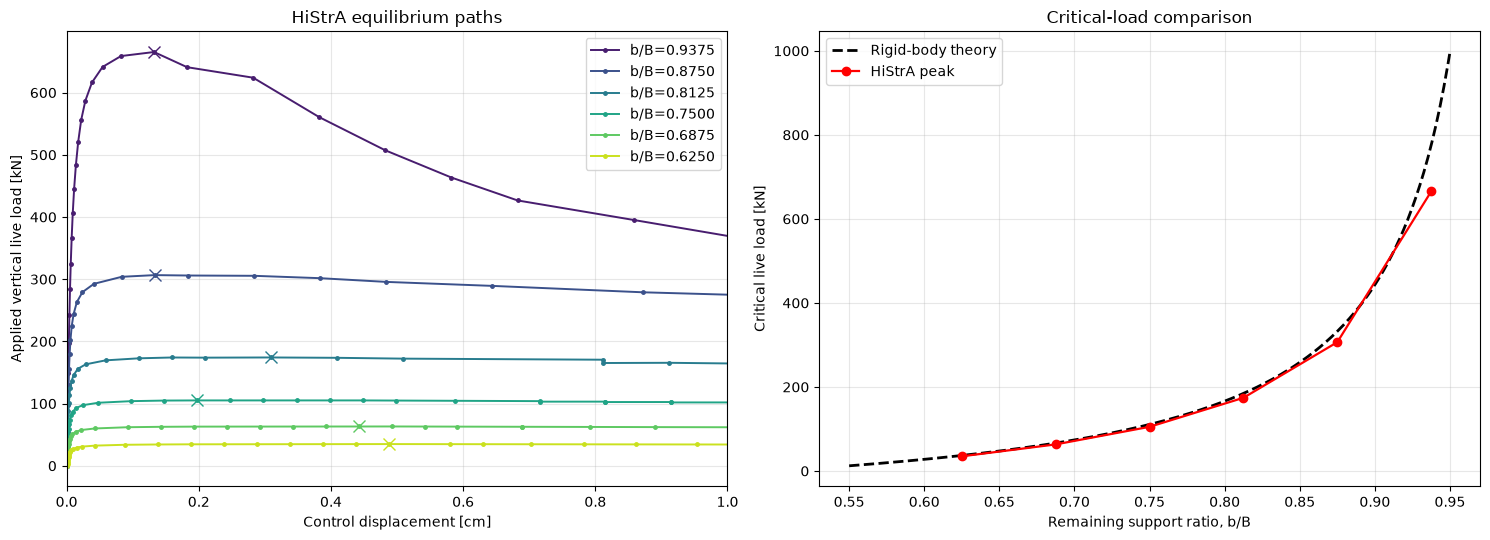

In [15]:
ratios = np.asarray([scenario.b_over_B for scenario in SCENARIOS])
theoretical_peaks = np.asarray([scenario.theoretical_fcr_kN for scenario in SCENARIOS])
numerical_peaks = np.asarray([results[ratio]["F_cr_num"] for ratio in ratios])
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(ratios)))

fig, (curve_axis, capacity_axis) = plt.subplots(1, 2, figsize=(15, 5.5))
for ratio, color in zip(ratios, colors):
    case = results[ratio]
    curve_axis.plot(
        case["displacements"], case["forces"], marker="o", markersize=2.5,
        linewidth=1.4, color=color, label=f"b/B={ratio:.4f}",
    )
    curve_axis.plot(case["displacements"][case["peak_idx"]], case["F_cr_num"], "x", color=color, markersize=8)
curve_axis.set_xlabel("Control displacement [cm]")
curve_axis.set_ylabel("Applied vertical live load [kN]")
curve_axis.set_title("HiStrA equilibrium paths")
curve_axis.grid(True, alpha=0.3)
curve_axis.set_xlim([0,1])
# curve_axis.set_ylim([0,50])
curve_axis.legend()

fine_ratio = np.linspace(0.55, 0.95, 300)
capacity_axis.plot(fine_ratio, critical_force_2d(fine_ratio), "k--", linewidth=2, label="Rigid-body theory")
capacity_axis.plot(ratios, numerical_peaks, "ro-", linewidth=1.6, label="HiStrA peak")
capacity_axis.set_xlabel("Remaining support ratio, b/B")
capacity_axis.set_ylabel("Critical live load [kN]")
capacity_axis.set_title("Critical-load comparison")
capacity_axis.grid(True, alpha=0.3)
capacity_axis.legend()
fig.tight_layout()
plt.show()

In [10]:
print("Capacity and analysis-completion summary")
print(
    f"{'Rows':>4} {'b/B':>8} {'d1 [m]':>9} {'d2 [m]':>9} {'F theory':>11} "
    f"{'F HiStrA':>11} {'Error %':>9} {'Steps':>7} {'Peak?':>8} {'Zero?':>8} {'Outcome':>18}"
)
for scenario in SCENARIOS:
    case = results[scenario.b_over_B]
    error_percent = 100.0 * (case["F_cr_num"] - scenario.theoretical_fcr_kN) / scenario.theoretical_fcr_kN
    print(
        f"{scenario.n_rows:4d} {scenario.b_over_B:8.4f} {scenario.d1_m:9.4f} "
        f"{scenario.d2_force_m:9.4f} {scenario.theoretical_fcr_kN:11.3f} "
        f"{case['F_cr_num']:11.3f} {error_percent:9.2f} {len(case['steps']):7d} "
        f"{str(case['peak_is_interior']):>8} {str(case['reached_zero_load']):>8} "
        f"{case['execution_outcome']:>18}"
    )

case_9375 = results[0.9375]
if not case_9375["peak_is_interior"]:
    print("\nNOTE: b/B=0.9375 has not reached an interior peak; its current maximum is a truncation bound, not Fcr.")
elif not case_9375["reached_zero_load"]:
    print("\nNOTE: b/B=0.9375 has a peak but its post-peak branch has not yet reached zero load.")

Capacity and analysis-completion summary
Rows      b/B    d1 [m]    d2 [m]    F theory    F HiStrA   Error %   Steps    Peak?    Zero?            Outcome
   1   0.9375    1.2600    0.1800     775.588     665.262    -14.22      27     True    False completed_at_configured_displacement_limit
   2   0.8750    1.0800    0.3600     332.395     306.592     -7.76      93     True    False completed_at_configured_displacement_limit
   3   0.8125    0.9000    0.5400     184.664     174.188     -5.67      63     True    False completed_at_configured_displacement_limit
   4   0.7500    0.7200    0.7200     110.798     105.124     -5.12     295     True    False completed_at_configured_displacement_limit
   5   0.6875    0.5400    0.9000      66.479      63.265     -4.83     442     True    False completed_at_configured_displacement_limit
   6   0.6250    0.3600    1.0800      36.933      34.937     -5.40     443     True     True          completed

NOTE: b/B=0.9375 has a peak but its post-peak b

## 7. Post-peak response for all six scour scenarios

Each row below compares one scenario against its own $d_1$, $d_2$, theoretical critical load, and zero-load rotation. Numerical horizontal and vertical displacements are increments from the numerical peak, measured at ModelPoint 16 relative to the translating scour-front pivot. The theoretical displacement uses the same tracked-point location.

The analytical curve is not rescaled to the numerical peak; therefore any critical-load mismatch—especially for $b/B=0.9375$—remains visible.

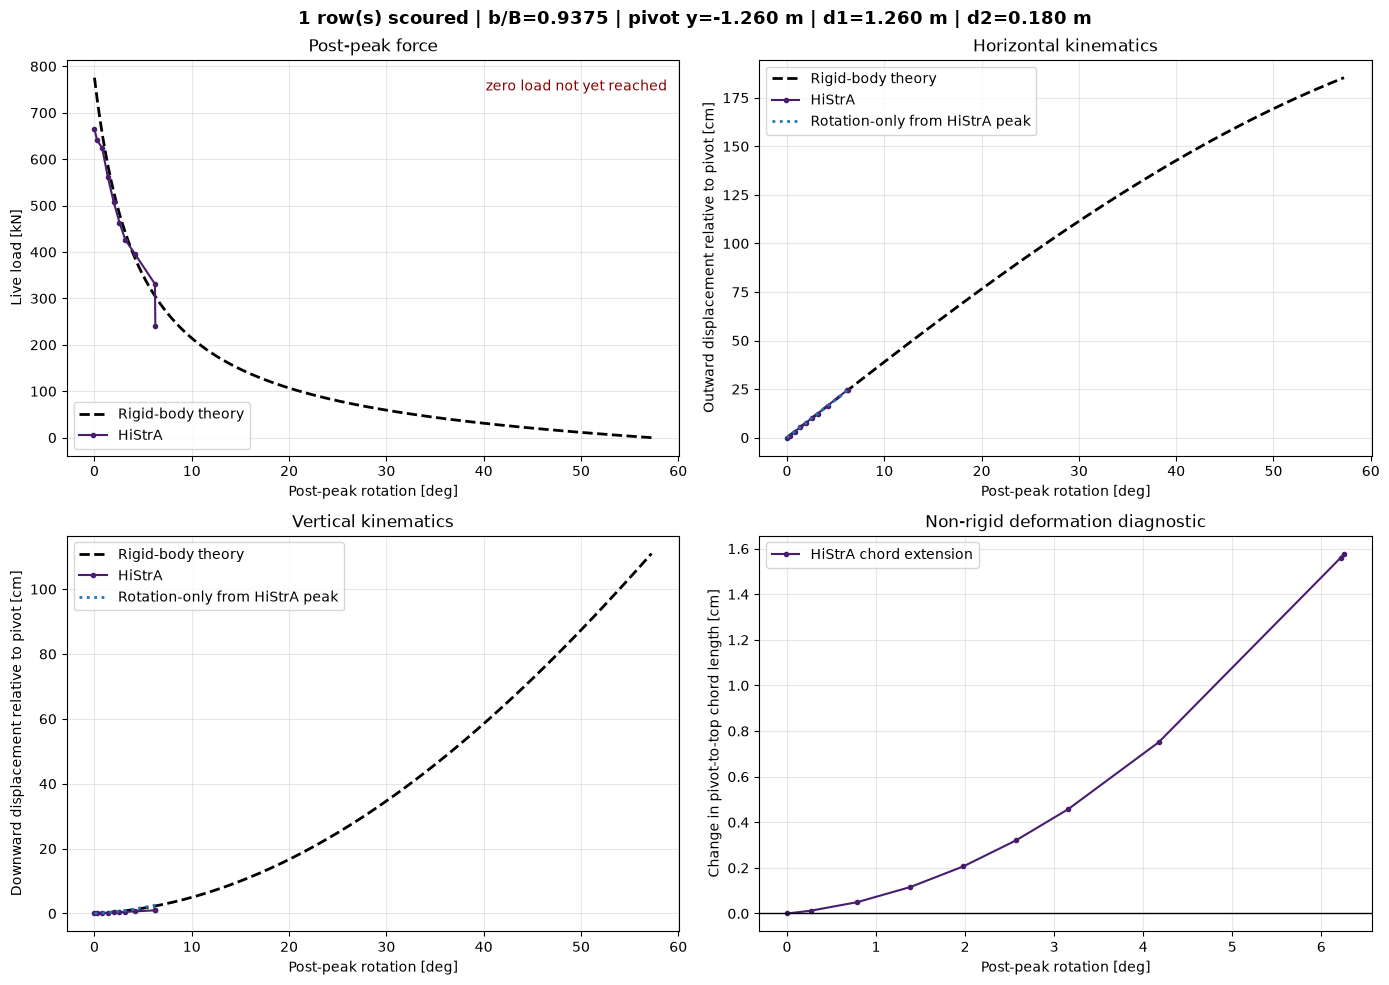

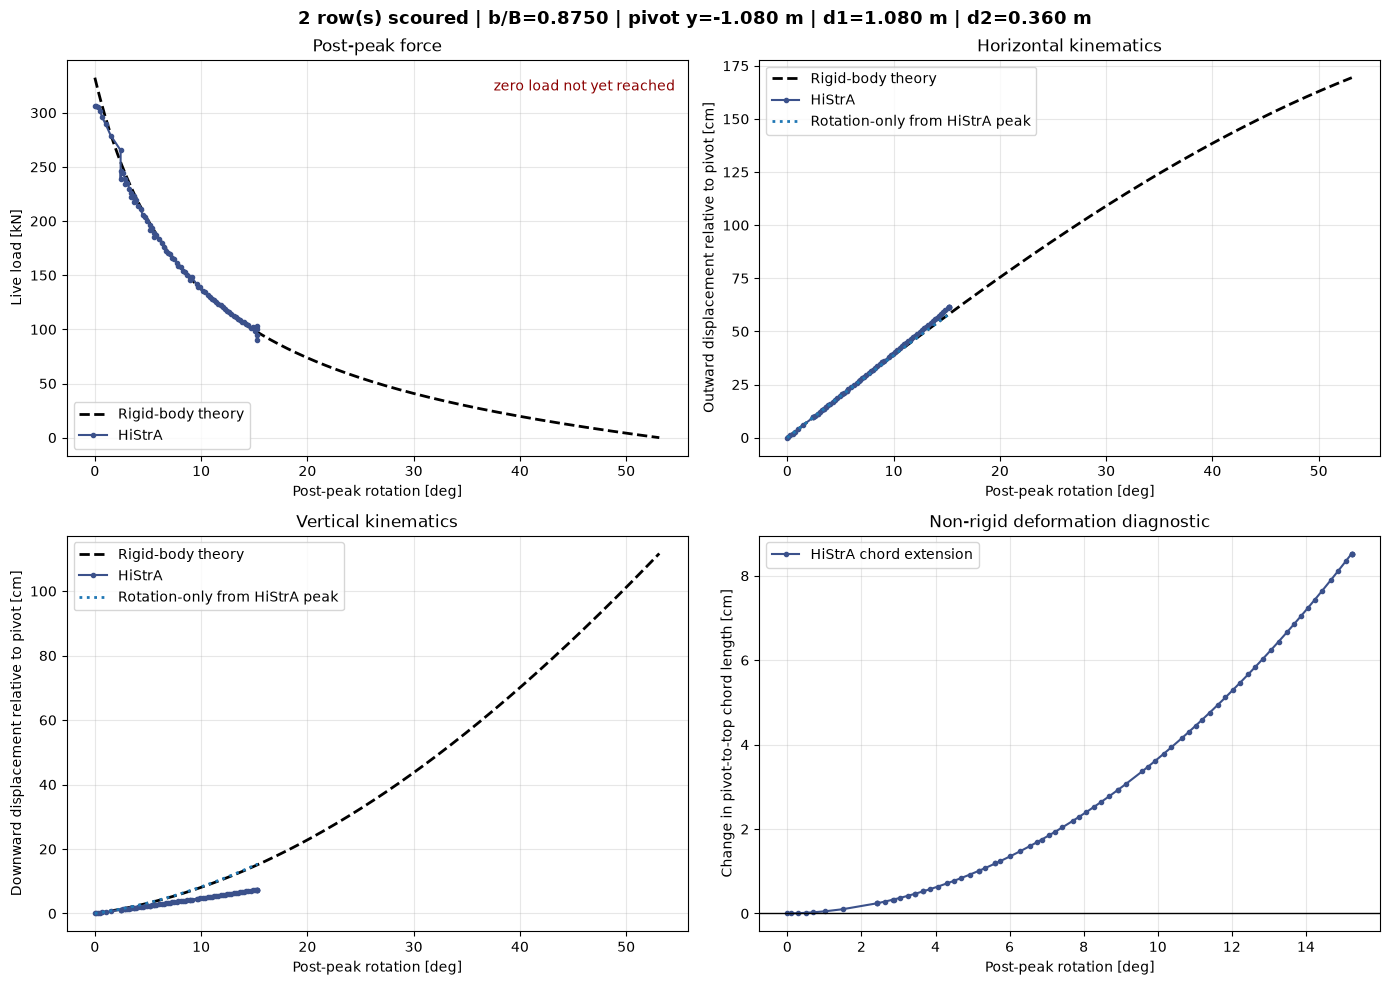

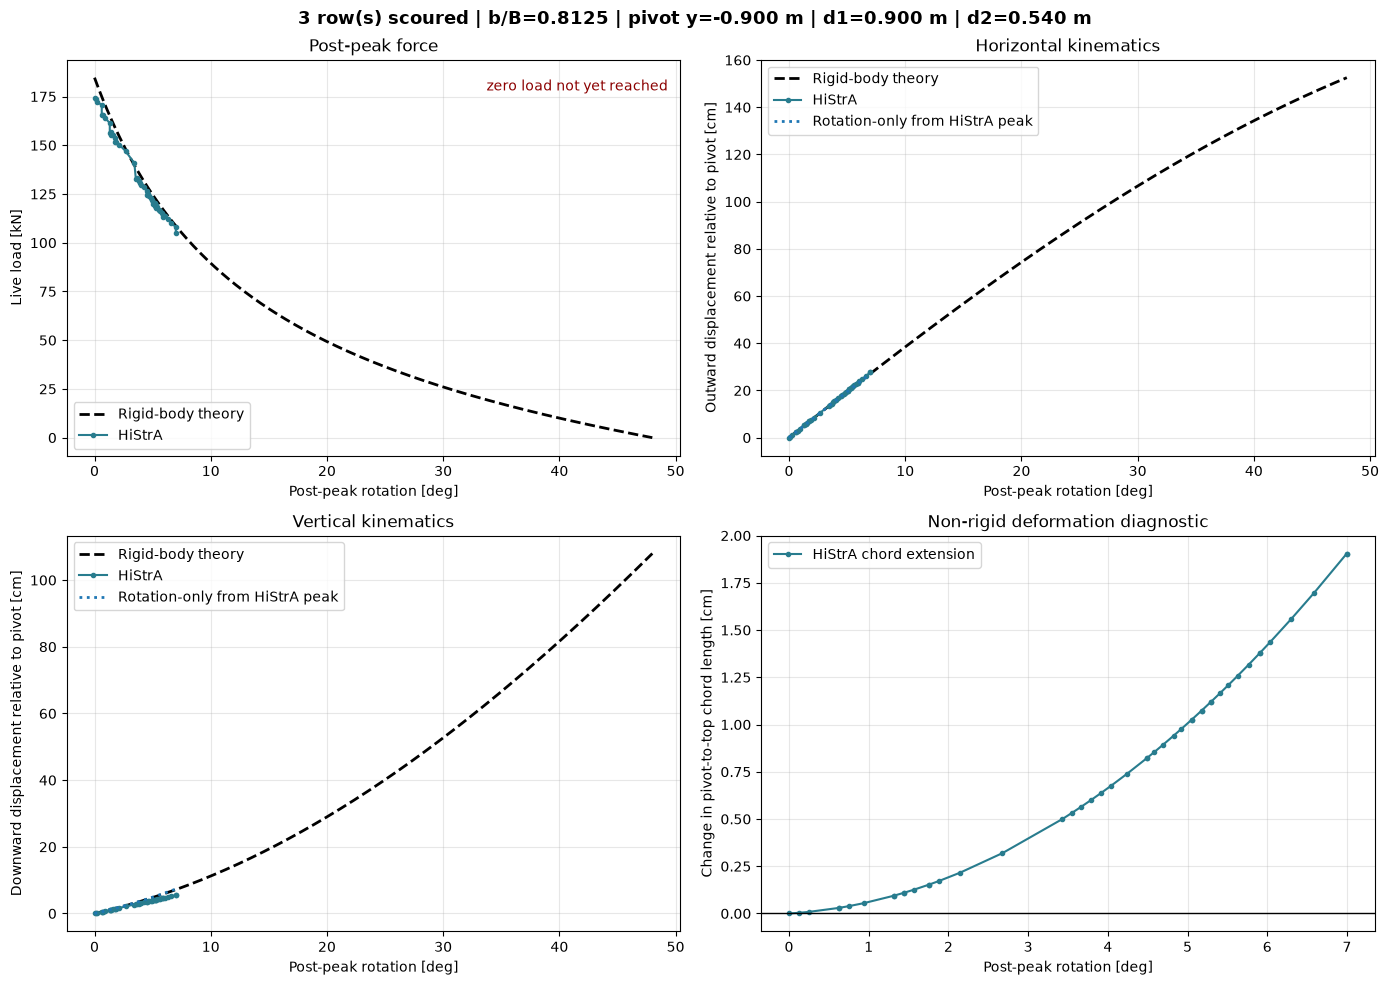

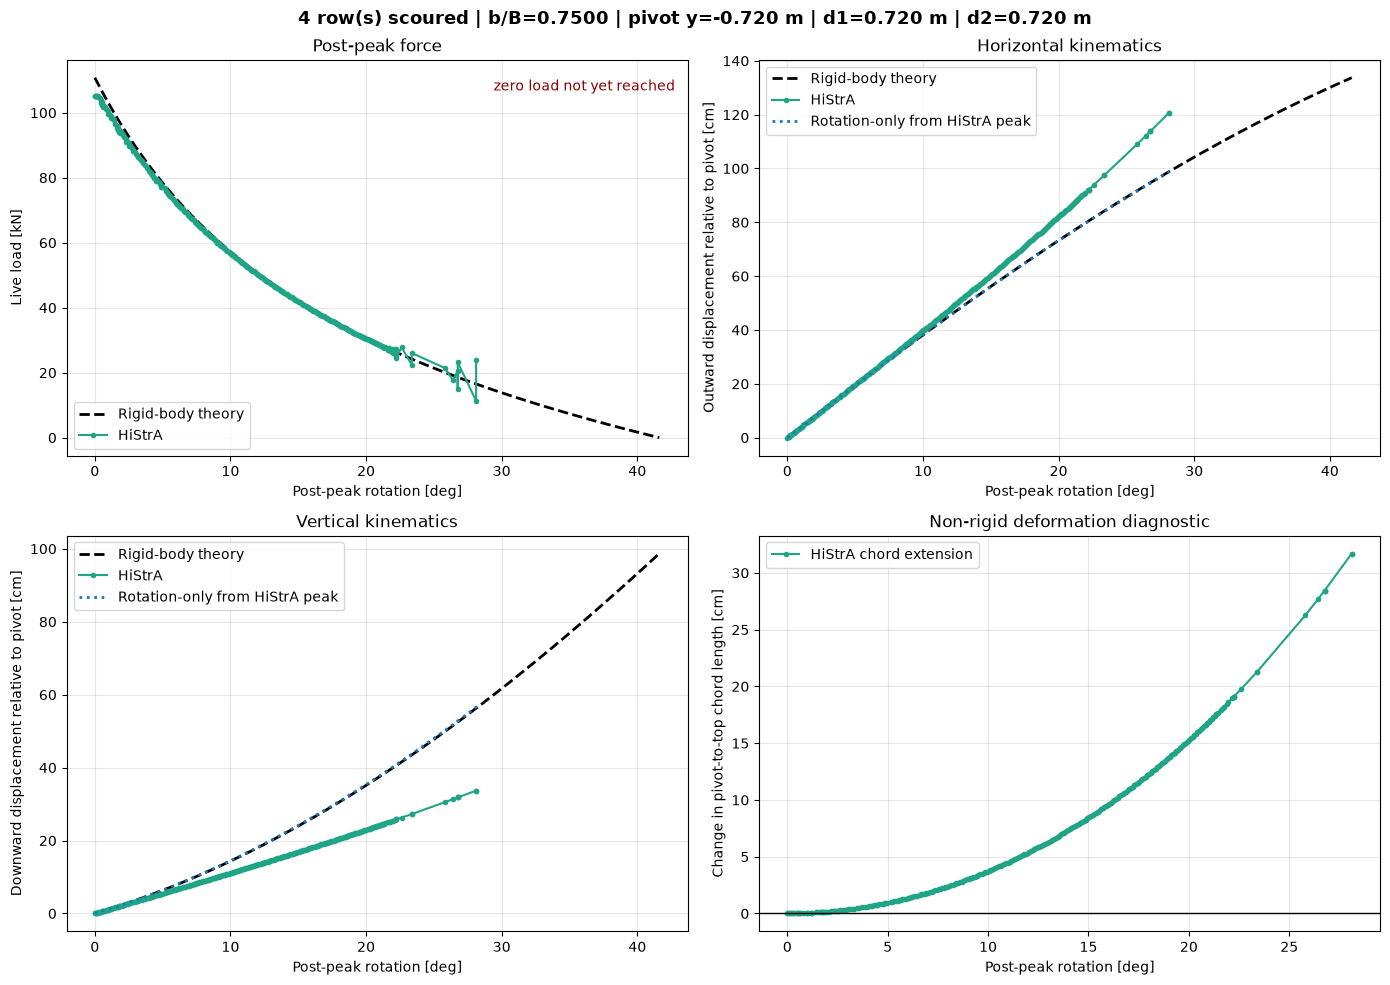

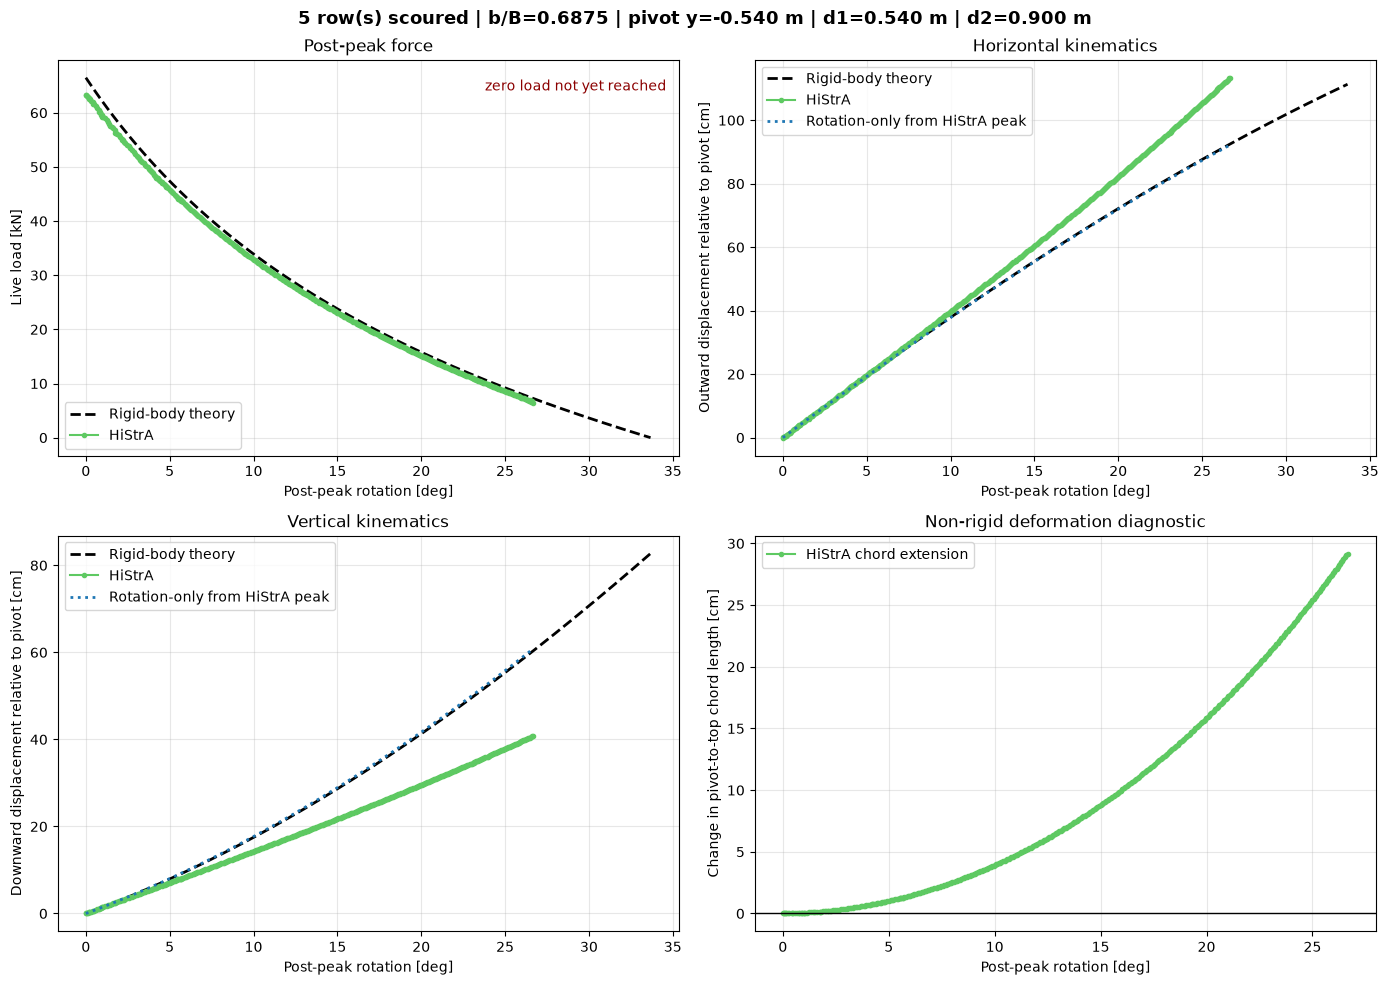

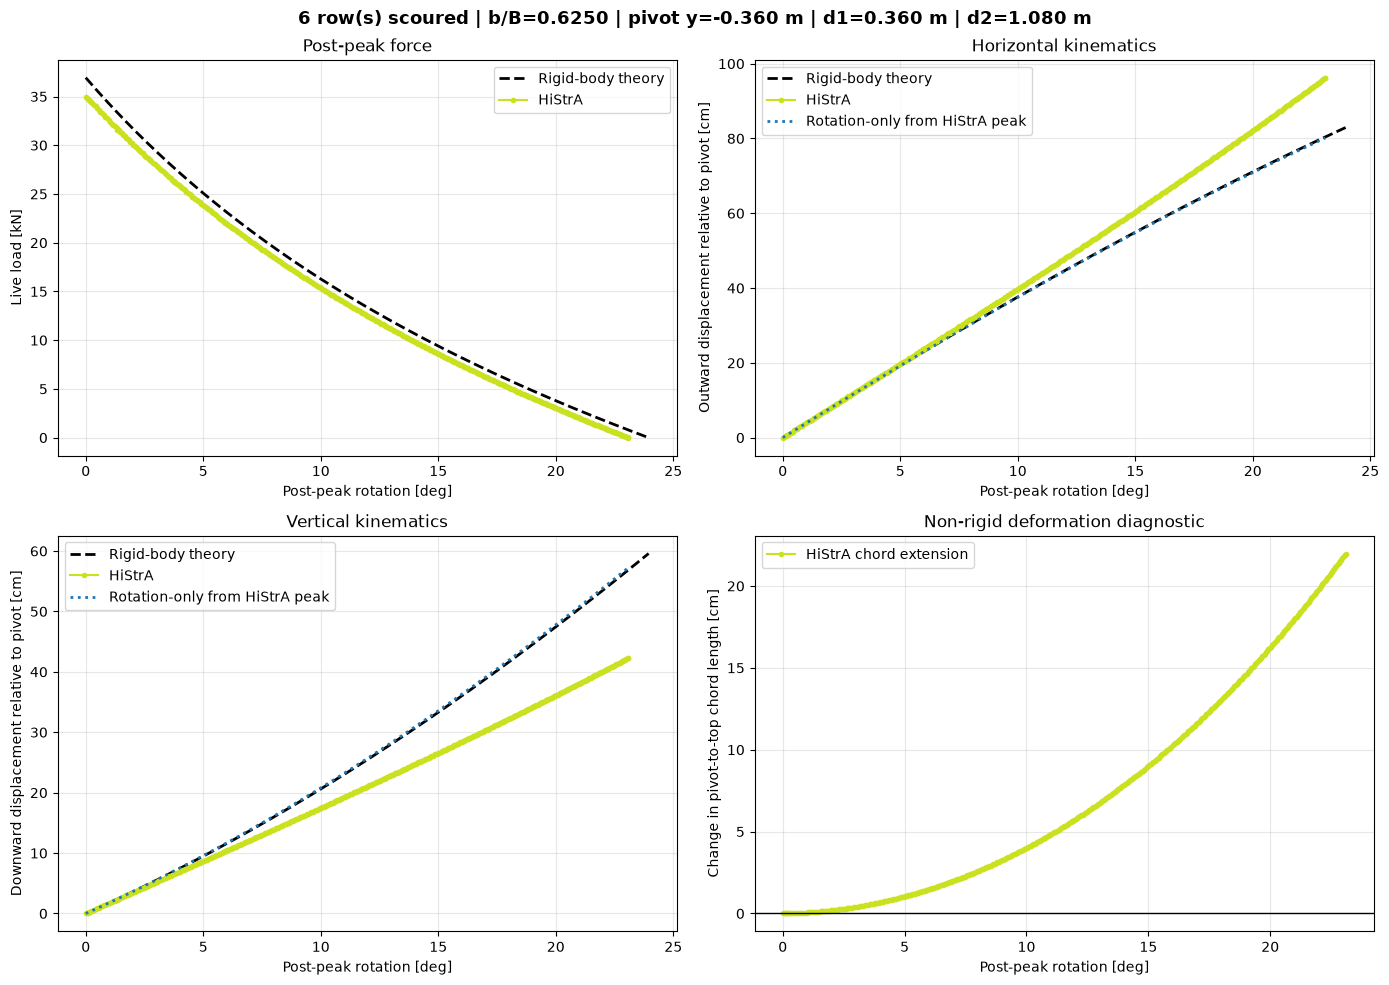

In [11]:
for scenario, color in zip(SCENARIOS, colors):
    case = results[scenario.b_over_B]
    theory = theoretical_rotation_path(scenario)
    figure, axes_grid = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes_grid.ravel()
    figure.suptitle(
        f"{scenario.n_rows} row(s) scoured | b/B={scenario.b_over_B:.4f} | "
        f"pivot y={scenario.pivot_y_m:.3f} m | d1={scenario.d1_m:.3f} m | d2={scenario.d2_force_m:.3f} m",
        fontsize=13,
        fontweight="bold",
    )

    axes[0].plot(theory["theta_deg"], theory["force_kN"], "k--", linewidth=2, label="Rigid-body theory")
    axes[0].plot(case["post_theta_deg"], case["post_force_kN"], ".-", color=color, label="HiStrA")
    axes[0].set_ylabel("Live load [kN]")
    axes[0].set_title("Post-peak force")

    axes[1].plot(theory["theta_deg"], theory["outward_uy_cm"], "k--", linewidth=2, label="Rigid-body theory")
    axes[1].plot(case["post_theta_deg"], case["post_outward_uy_cm"], ".-", color=color, label="HiStrA")
    axes[1].plot(case["post_theta_deg"], case["post_rigid_outward_cm"], ":", color="tab:blue", linewidth=2, label="Rotation-only from HiStrA peak")
    axes[1].set_ylabel("Outward displacement relative to pivot [cm]")
    axes[1].set_title("Horizontal kinematics")

    axes[2].plot(theory["theta_deg"], theory["downward_uz_cm"], "k--", linewidth=2, label="Rigid-body theory")
    axes[2].plot(case["post_theta_deg"], case["post_downward_uz_cm"], ".-", color=color, label="HiStrA")
    axes[2].plot(case["post_theta_deg"], case["post_rigid_downward_cm"], ":", color="tab:blue", linewidth=2, label="Rotation-only from HiStrA peak")
    axes[2].set_ylabel("Downward displacement relative to pivot [cm]")
    axes[2].set_title("Vertical kinematics")

    axes[3].plot(case["post_theta_deg"], case["post_chord_extension_cm"], ".-", color=color, label="HiStrA chord extension")
    axes[3].axhline(0.0, color="k", linewidth=1)
    axes[3].set_ylabel("Change in pivot-to-top chord length [cm]")
    axes[3].set_title("Non-rigid deformation diagnostic")

    for axis in axes:
        axis.set_xlabel("Post-peak rotation [deg]")
        axis.grid(True, alpha=0.3)
        axis.legend()
    if not case["reached_zero_load"]:
        axes[0].text(
            0.98, 0.95, "zero load not yet reached", transform=axes[0].transAxes,
            ha="right", va="top", color="darkred",
        )
    figure.tight_layout()
    plt.show()